In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
# --- CONFIGURATION ---
# This is where you adjust the model's sensitivity
CONFIG = {
    'WINDOW_RECENT_DAYS': 7,    # Short-term period (recent trend)
    'WINDOW_HISTORY_DAYS': 14,  # Medium-term period (for comparison)
    'TARGET_WINDOW': 10,        # Prediction window (churn in the next X days)
    'STEP_SIZE': 7,             # We advance by 7 days with each iteration (Data Augmentation)
    'CHURN_EVENT': 'Cancellation Confirmation'
}

In [3]:
def load_and_clean_data(csv_path):
    """
    Loads the data and converts the temporal types.
    """
    print("Loading and cleaning the data...")
    df = pd.read_parquet(csv_path)

    df.drop("ts", axis=1)

    # On supprime les lignes sans userId valide (ex: utilisateurs non loggués)
    df = df[df['userId'].notna()]

    # Converting categorical columns to optimize memory
    categorical_cols = ['gender', 'level', 'page', 'method']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print(f"Data ready: {df.shape[0]} lines, from {df['time'].min()} to {df['time'].max()}")
    return df

In [4]:
#kaggle_challenge/data/churn-prediction-25-26/train.parquet
df=load_and_clean_data("../../../data/churn-prediction-25-26/train.parquet")

Loading and cleaning the data...
Data ready: 17499636 lines, from 2018-10-01 00:00:01 to 2018-11-20 00:00:00


In [24]:
def device_type(s: str):
    if "Windows" in s:
        return "Windows"
    elif "Macintosh" in s:
        return "Macintosh"
    elif "Linux" in s:
        return "Linux"
    elif "iPad" in s:
        return "iPad"
    elif "iPhone" in s:
        return "iPhone"
    else:
        return "Different Device"


def exact_device_type(df: pd.DataFrame):
    """
    From a dataframe with at least ['userId', 'userAgent'],
    extract the device type and return a wide one-hot table by user.
    """
    df = df.copy()

    #Extract the part inside parentheses from the userAgent string
    df["device_used"] = df["userAgent"].apply(
        lambda x: x[x.index("(") : x.index(")") + 1]
        if isinstance(x, str) and "(" in x and ")" in x
        else None
    )
    # Map to simplified device categories
    df["exact_device"] = df["device_used"].apply(
        lambda x: device_type(x)
        if isinstance(x, str) else None)

    df_a = df[["userId", "exact_device"]]
    df_b = df_a.drop_duplicates().copy()

    df_b.loc[:, "val"] = 1

    # Pivot to get one column per device type
    df_c = df_b.pivot(index="userId", columns="exact_device", values="val")

    df_c = df_c.fillna(0.0)

    return df_c


def compute_features_at_anchor(df_window, anchor_date):
    """
    Compute features for all users who are active at a specific date (anchor_date).
    """
    # 1. Time slicing (Past only!)
    # "Recent" period: [Anchor - WINDOW_RECENT_DAYS, Anchor]
    start_recent = anchor_date - timedelta(days=CONFIG['WINDOW_RECENT_DAYS'])

    # "Historical" period: [Anchor - (WINDOW_HISTORY_DAYS + WINDOW_RECENT_DAYS), Anchor - WINDOW_RECENT_DAYS]
    # (we avoid overlap)
    start_history = start_recent - timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'])

    # Global filtering (keep only rows that are needed for feature computation)
    df_past = df_window[
        (df_window['time'] >= start_history) & (df_window['time'] <= anchor_date)
    ].copy()

    if df_past.empty:
        return None

    # Split into two subsets to compare trends
    mask_recent = df_past['time'] >= start_recent
    df_recent = df_past[mask_recent]
    df_history = df_past[~mask_recent]

    # --- A. STATIC FEATURES & STATE (Last known value) ---
    # Take the last row of each user to get their current state (Paid/Free, etc.)
    last_status = df_past.sort_values('time').groupby('userId').last()

    features = pd.DataFrame(index=df_past['userId'].unique())

    # Simple encoding: Level (1 if paid, 0 if free) - Only if the column exists
    if 'level' in last_status.columns:
        features['is_paid'] = (last_status['level'] == 'paid').astype(int)

    # Gender (1 if F, 0 if M for example)
    if 'gender' in last_status.columns:
        features['gender_F'] = (last_status['gender'] == 'F').astype(int)

    # Device type (one-hot by user) from userAgent if available
    if 'userAgent' in df_past.columns:
        # Use all past logs so we capture any device they used up to the anchor date
        device_features = exact_device_type(df_past[['userId', 'userAgent']])
        # Join on userId index
        features = features.join(device_features, how='left')

    # Recency: Days since the very last action
    last_action_date = df_past.groupby('userId')['time'].max()
    features['days_since_last_action'] = (
        (anchor_date - last_action_date).dt.total_seconds() / (3600 * 24)
    )

    # --- B. ACTIVITY FEATURES (Counts) ---
    # Helper function to avoid repetition
    def get_counts(df_sub, prefix):
        counts = df_sub.groupby('userId').agg({
            'page': 'count',      # Total actions
            'song': 'count',      # Total songs
            'sessionId': 'nunique',  # Total sessions
            'status': 'nunique'   # Number of distinct status codes (errors etc.)
        }).rename(columns={
            'page': f'{prefix}_actions',
            'song': f'{prefix}_songs',
            'sessionId': f'{prefix}_sessions',
            'status': f'{prefix}_status'
        })

        # Specific events (Thumbs Up, Thumbs Down, Errors, Add to Playlist, etc.)
        events = df_sub[df_sub['page'].isin([
            'Thumbs Up',
            'Thumbs Down',
            'Error',
            'Add to Playlist',
            'Add Friend',
            'Submit Upgrade',
            'Upgrade',
            'Downgrade',
            'Submit Downgrade',
            'Roll Advert'
        ])]

        if not events.empty:
            event_counts = pd.crosstab(events['userId'], events['page']).add_prefix(f'{prefix}_')
            counts = counts.merge(event_counts, on='userId', how='left')

        return counts

    feats_recent = get_counts(df_recent, 'recent')
    feats_history = get_counts(df_history, 'history')

    # Merge (including device features that were already joined above)
    features = features.join(feats_recent, how='left').join(feats_history, how='left').fillna(0)

    # --- C. TREND FEATURES (EVOLUTION) ---
    # This is key for churn detection: is activity decreasing?
    # We compute daily averages to compare periods of different lengths

    avg_songs_recent = features['recent_songs'] / CONFIG['WINDOW_RECENT_DAYS']
    avg_songs_history = features['history_songs'] / CONFIG['WINDOW_HISTORY_DAYS']

    # Trend ratio: (Recent + epsilon) / (History + epsilon)
    # If < 1: activity is going down
    epsilon = 0.1  # To avoid division by zero
    features['trend_song_consumption'] = (avg_songs_recent + epsilon) / (avg_songs_history + epsilon)

    # Error ratio (is the user facing more bugs recently?)
    if 'recent_Error' in features.columns and 'history_Error' in features.columns:
        features['trend_error_rate'] = (features['recent_Error'] + epsilon) / (features['history_Error'] + epsilon)

    # Status ratio (is the user facing more bugs recently?)
    if 'recent_status' in features.columns and 'history_status' in features.columns:
        features['trend_status_rate'] = (features['recent_status'] + epsilon) / (features['history_status'] + epsilon)

    # Thumbs Up ratio (is the user liking more songs?)
    if 'recent_Thumbs Up' in features.columns and 'history_Thumbs Up' in features.columns:
        features['trend_thumbs_up'] = (features['recent_Thumbs Up'] + epsilon) / (features['history_Thumbs Up'] + epsilon)

    # Thumbs Down ratio (is the user liking more songs?)
    if 'recent_Thumbs Down' in features.columns and 'history_Thumbs Down' in features.columns:
        features['trend_thumbs_down'] = (features['recent_Thumbs Down'] + epsilon) / (features['history_Thumbs Down'] + epsilon)

    # Add to Playlist ratio (is the user liking more songs?)
    if 'recent_Add to Playlist' in features.columns and 'history_Add to Playlist' in features.columns:
        features['trend_add_to_playlist'] = (features['recent_Add to Playlist'] + epsilon) / (features['history_Add to Playlist'] + epsilon)

    # Add Friend ratio (is the user liking more songs?)
    if 'recent_Add Friend' in features.columns and 'history_Add Friend' in features.columns:
        features['trend_add_friend'] = (features['recent_Add Friend'] + epsilon) / (features['history_Add Friend'] + epsilon)

    # Submit Upgrade ratio (is the user liking more songs?)
    if 'recent_Submit Upgrade' in features.columns and 'history_Submit Upgrade' in features.columns:
        features['trend_submit_upgrade'] = (features['recent_Submit Upgrade'] + epsilon) / (features['history_Submit Upgrade'] + epsilon)

    # Upgrade ratio (is the user liking more songs?)
    if 'recent_Upgrade' in features.columns and 'history_Upgrade' in features.columns:
        features['trend_upgrade'] = (features['recent_Upgrade'] + epsilon) / (features['history_Upgrade'] + epsilon)

    # Downgrade ratio (is the user liking more songs?)
    if 'recent_Downgrade' in features.columns and 'history_Downgrade' in features.columns:
        features['trend_downgrade'] = (features['recent_Downgrade'] + epsilon) / (features['history_Downgrade'] + epsilon)

    # Submit Downgrade ratio (is the user liking more songs?)
    if 'recent_Submit Downgrade' in features.columns and 'history_Submit Downgrade' in features.columns:
        features['trend_Submit downgrade'] = (features['recent_Submit Downgrade'] + epsilon) / (features['history_Submit Downgrade'] + epsilon)

    # Roll Advert ratio (is the user liking more songs?)
    if 'recent_Roll Advert' in features.columns and 'history_Roll Advert' in features.columns:
        features['trend_Roll Advert'] = (features['recent_Roll Advert'] + epsilon) / (features['history_Roll Advert'] + epsilon)

    # Add the anchor date for tracking
    features['anchor_date'] = anchor_date

    return features


In [25]:
def run_feature_engineering_pipeline(df_logs):
    """
    Runs the sliding window loop and generates the full Train/Test dataset.
    """
    print("Starting Sliding Window pipeline...")

    min_date = df_logs['time'].min()
    max_date = df_logs['time'].max()

    # We start only when we have enough history
    start_anchor = min_date + timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'] + CONFIG['WINDOW_RECENT_DAYS'])
    # We stop before the very end so we still have future data to build the target
    end_anchor = max_date - timedelta(days=CONFIG['TARGET_WINDOW'])

    current_date = start_anchor
    final_datasets = []

    while current_date <= end_anchor:
        print(f"Processing window for anchor date: {current_date.date()}")

        # 1. Generate features (X) for this anchor date
        # Use a wide view on the data to avoid unnecessary copies
        window_start = current_date - timedelta(days=CONFIG['WINDOW_HISTORY_DAYS'] +
                                                     CONFIG['WINDOW_RECENT_DAYS'] + 1)
        df_view = df_logs[(df_logs['time'] >= window_start) & (df_logs['time'] <= max_date)]

        features = compute_features_at_anchor(df_view, current_date)

        if features is None or features.empty:
            current_date += timedelta(days=CONFIG['STEP_SIZE'])
            continue

        # 2. Generate the target (Y) - Future
        # Look into the future [Anchor, Anchor + TARGET_WINDOW days]
        future_mask = (df_view['time'] > current_date) & \
                      (df_view['time'] <= current_date + timedelta(days=CONFIG['TARGET_WINDOW']))

        future_data = df_view[future_mask]

        # Identify churners
        churn_users = future_data[future_data['page'] == CONFIG['CHURN_EVENT']]['userId'].unique()

        features['target_churn'] = 0
        features.loc[features.index.isin(churn_users), 'target_churn'] = 1

        final_datasets.append(features)

        # Move the sliding window forward
        current_date += timedelta(days=CONFIG['STEP_SIZE'])

    # Final concatenation
    if not final_datasets:
        print("Warning: No valid window generated (dataset too short?)")
        return pd.DataFrame()

    full_dataset = pd.concat(final_datasets).reset_index().rename(columns={'index': 'userId'})

    print(f"Pipeline finished. Dataset generated with shape: {full_dataset.shape}")
    return full_dataset


In [26]:
df_train_ready = run_feature_engineering_pipeline(df)

Starting Sliding Window pipeline...
Processing window for anchor date: 2018-10-22
Processing window for anchor date: 2018-10-29
Processing window for anchor date: 2018-11-05
Pipeline finished. Dataset generated with shape: (50548, 51)


In [27]:
print(df_train_ready['target_churn'].value_counts())
df_train_ready.head()

target_churn
0    48185
1     2363
Name: count, dtype: int64


,userId,is_paid,gender_F,Linux,Macintosh,Windows,iPad,iPhone,days_since_last_action,recent_actions,...,trend_thumbs_down,trend_add_to_playlist,trend_add_friend,trend_submit_upgrade,trend_upgrade,trend_downgrade,trend_Submit downgrade,trend_Roll Advert,anchor_date,target_churn
0,1749042,1,0,0.0,0.0,1.0,0.0,0.0,0.946956,94.0,...,0.010989,0.067524,0.005525,1.000000,1.000000,0.436620,1.000000,1.000000,2018-10-22 00:00:01,0
1,1563081,1,1,0.0,1.0,0.0,0.0,0.0,2.354271,102.0,...,31.000000,11.000000,11.000000,1.000000,1.000000,0.090909,1.000000,1.000000,2018-10-22 00:00:01,0
2,1697168,0,1,0.0,1.0,0.0,0.0,0.0,2.014664,98.0,...,0.019608,0.382716,0.677419,1.000000,0.047619,0.024390,0.090909,0.226519,2018-10-22 00:00:01,0
3,1222580,0,0,0.0,1.0,0.0,0.0,0.0,2.366354,20.0,...,0.139073,0.002494,0.003984,0.090909,0.024390,0.006623,0.047619,0.154930,2018-10-22 00:00:01,1
4,1714398,1,1,0.0,0.0,1.0,0.0,0.0,0.080394,542.0,...,1.000000,1.610687,0.900990,1.000000,1.000000,4.333333,1.000000,0.047619,2018-10-22 00:00:01,0


In [28]:
df_train_ready[df_train_ready["userId"]=="1697168"]

,userId,is_paid,gender_F,Linux,Macintosh,Windows,iPad,iPhone,days_since_last_action,recent_actions,...,trend_thumbs_down,trend_add_to_playlist,trend_add_friend,trend_submit_upgrade,trend_upgrade,trend_downgrade,trend_Submit downgrade,trend_Roll Advert,anchor_date,target_churn
2,1697168,0,1,0.0,1.0,0.0,0.0,0.0,2.014664,98.0,...,0.019608,0.382716,0.677419,1.0,0.047619,0.02439,0.090909,0.226519,2018-10-22 00:00:01,0
17502,1697168,0,1,0.0,1.0,0.0,0.0,0.0,0.570116,293.0,...,1.000000,0.607843,1.476190,1.0,11.000000,1.00000,1.000000,2.134752,2018-10-29 00:00:01,0
34335,1697168,1,1,0.0,1.0,0.0,0.0,0.0,0.015150,207.0,...,0.523810,1.000000,0.019608,11.0,3.727273,11.00000,1.000000,0.208211,2018-11-05 00:00:01,0


In [29]:
def train_eval_model(df_train):
    """
    Train an XGBoost model with GroupKFold cross-validation
    to avoid leakage between sliding windows of the same user.
    """
    print("--- Starting model training ---")

    # 1. Feature preparation
    # Exclude technical columns that are not input features
    ignore_cols = ['userId', 'target_churn', 'anchor_date', 'ts_date']
    features = [c for c in df_train.columns if c not in ignore_cols]

    X = df_train[features]
    y = df_train['target_churn']
    groups = df_train['userId']  # Crucial for GroupKFold to group by user

    print(f"Detected features ({len(features)}): {features}")

    # 2. Model definition
    clf = xgb.XGBClassifier(
        n_estimators=500,        # Number of trees
        learning_rate=0.03,      # Learning rate (smaller = more precise but slower)
        max_depth=5,             # Tree depth
        subsample=0.8,           # Row subsampling to reduce overfitting
        colsample_bytree=0.8,    # Column subsampling to reduce overfitting
        scale_pos_weight=10,     # Handle class imbalance (churners are rare)
        eval_metric='auc',
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=50
    )

    # 3. Cross-validation (5 folds)
    gkf = GroupKFold(n_splits=5)
    fold_scores = []
    feature_importance_df = pd.DataFrame(index=features)
    feature_importance_df['gain'] = 0

    for i, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        # Fold score
        preds = clf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
        fold_scores.append(score)

        # Feature importance
        feature_importance_df['gain'] += clf.feature_importances_
        print(f"Fold {i+1} AUC: {score:.4f}")

    print(f"\n>>> FINAL MEAN SCORE (AUC): {np.mean(fold_scores):.4f} <<<")

    # 4. Display most important features
    feature_importance_df['gain'] /= 5
    feature_importance_df = feature_importance_df.sort_values('gain', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='gain', y=feature_importance_df.index[:15], data=feature_importance_df.iloc[:15])
    plt.title('Top 15 Most Important Features')
    plt.tight_layout()
    plt.show()  # If you are in a notebook; otherwise you can use plt.savefig('importance.png')

    # Final training on the FULL dataset for deployment / submission
    print("Retraining final model on the full dataset...")
    clf.set_params(early_stopping_rounds=None)
    clf.fit(X, y, verbose=False)

    return clf, features


In [55]:
def build_model(model_type: str, use_early_stopping: bool = True):
    """
    Factory function to build a model by type.
    """
    model_type = model_type.lower()

    if model_type == "xgb":
        # XGBoost (same spirit as your original settings)
        return xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=10,
            eval_metric="auc",
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50 if use_early_stopping else None,
        )
        """
        return xgb.XGBClassifier(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=10,
            eval_metric="auc",
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50 if use_early_stopping else None,
        )
        """


    elif model_type == "logreg":
        # Logistic Regression (good baseline, handles imbalance)
        return Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    class_weight="balanced",
                    max_iter=5000,   # more iterations
                    solver="lbfgs",
                    n_jobs=-1,
                ))
            ]
        )

    elif model_type == "rf":
        # Random Forest (non-linear, robust, works well with mixed features)
        return RandomForestClassifier(
            n_estimators=400,
            max_depth=None,
            min_samples_leaf=10,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}")


def train_eval_model(df_train, model_type: str = "xgb"):
    """
    Train a classification model (XGBoost / Logistic Regression / RandomForest, etc.)
    with GroupKFold cross-validation to avoid leakage between windows of the same user.

    Parameters
    ----------
    df_train : pd.DataFrame
        Training data with features + 'target_churn' + 'userId' etc.
    model_type : str
        One of: "xgb", "logreg", "rf".
    """
    print(f"--- Starting model training [{model_type}] ---")

    # 1. Feature preparation
    ignore_cols = ['userId', 'target_churn', 'anchor_date', 'ts_date']
    features = [c for c in df_train.columns if c not in ignore_cols]

    X = df_train[features]
    y = df_train['target_churn'].values  # as numpy array for indexing
    groups = df_train['userId']          # Crucial for GroupKFold to group by user

    print(f"Detected features ({len(features)}): {features}")

    # 2. Cross-validation (5 folds)
    gkf = GroupKFold(n_splits=5)
    fold_scores = []
    feature_importance = np.zeros(len(features), dtype=float)

    # To build a global confusion matrix (out-of-fold predictions)
    oof_pred_proba = np.zeros(len(df_train))
    oof_true = y.copy()

    for i, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        print(f"\nFold {i + 1} / 5")

        X_tr, y_tr = X.iloc[train_idx], y[train_idx]
        X_val, y_val = X.iloc[val_idx], y[val_idx]

        # Build a fresh model for each fold (no leakage between folds)
        clf = build_model(model_type, use_early_stopping=True)

        # XGBoost supports eval_set & early stopping; others just ignore it
        if model_type == "xgb":
            clf.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
        else:
            clf.fit(X_tr, y_tr)

        # --- Fold score ---
        preds = clf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, preds)
        fold_scores.append(score)
        print(f"Fold {i + 1} AUC: {score:.4f}")

        # store out-of-fold probabilities for confusion matrix later
        oof_pred_proba[val_idx] = preds

        # --- Feature importance accumulation ---
        if model_type == "logreg":
            # Get the inner LogisticRegression model from the pipeline
            lr = clf.named_steps["model"]
            coefs = lr.coef_[0]
            feature_importance += np.abs(coefs)

        elif hasattr(clf, "feature_importances_"):
            # Works for RandomForest, XGBoost, etc.
            feature_importance += clf.feature_importances_

        # For other model types without a notion of importance, we could skip
        # or implement a permutation importance later.

    print(f"\n>>> FINAL MEAN SCORE (AUC) [{model_type}]: {np.mean(fold_scores):.4f} <<<")

    # 2.5 Confusion matrix based on out-of-fold predictions
    threshold = 0.5  # you can change this if you tune the threshold
    oof_pred_label = (oof_pred_proba >= threshold).astype(int)

    cm = confusion_matrix(oof_true, oof_pred_label)
    tn, fp, fn, tp = cm.ravel()
    print("\nConfusion Matrix (OOF, threshold = 0.5):")
    print(cm)
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    print("#"*50)
    print("Classification Report")
    print(classification_report(oof_true, oof_pred_label))
    print("#"*50)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Pred: No Churn', 'Pred: Churn'],
        yticklabels=['True: No Churn', 'True: Churn']
    )
    plt.title(f'Confusion Matrix (OOF) - {model_type}')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    # 3. Feature importance DataFrame (if we collected something)
    feature_importance_df = pd.DataFrame(
        {"gain": feature_importance / len(fold_scores)},
        index=features,
    ).sort_values("gain", ascending=False)

    # 4. Plot top features (if any non-zero importances)
    if feature_importance_df['gain'].abs().sum() > 0:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            x='gain',
            y=feature_importance_df.index[:15],
            data=feature_importance_df.iloc[:15]
        )
        plt.title(f'Top 15 Most Important Features ({model_type})')
        plt.tight_layout()
        plt.show()
    else:
        print("No feature importance available for this model type.")

    # 5. Final training on FULL dataset for deployment / submission
    print(f"\nRetraining final [{model_type}] model on the full dataset...")
    final_clf = build_model(model_type, use_early_stopping=False)

    if model_type == "xgb":
        # No eval_set / early stopping for final fit
        final_clf.fit(X, y, verbose=False)
    else:
        final_clf.fit(X, y)

    return final_clf, features


--- Starting model training [xgb] ---
Detected features (48): ['is_paid', 'gender_F', 'Linux', 'Macintosh', 'Windows', 'iPad', 'iPhone', 'days_since_last_action', 'recent_actions', 'recent_songs', 'recent_sessions', 'recent_status', 'recent_Add Friend', 'recent_Add to Playlist', 'recent_Downgrade', 'recent_Error', 'recent_Roll Advert', 'recent_Submit Downgrade', 'recent_Submit Upgrade', 'recent_Thumbs Down', 'recent_Thumbs Up', 'recent_Upgrade', 'history_actions', 'history_songs', 'history_sessions', 'history_status', 'history_Add Friend', 'history_Add to Playlist', 'history_Downgrade', 'history_Error', 'history_Roll Advert', 'history_Submit Downgrade', 'history_Submit Upgrade', 'history_Thumbs Down', 'history_Thumbs Up', 'history_Upgrade', 'trend_song_consumption', 'trend_error_rate', 'trend_status_rate', 'trend_thumbs_up', 'trend_thumbs_down', 'trend_add_to_playlist', 'trend_add_friend', 'trend_submit_upgrade', 'trend_upgrade', 'trend_downgrade', 'trend_Submit downgrade', 'trend_Roll

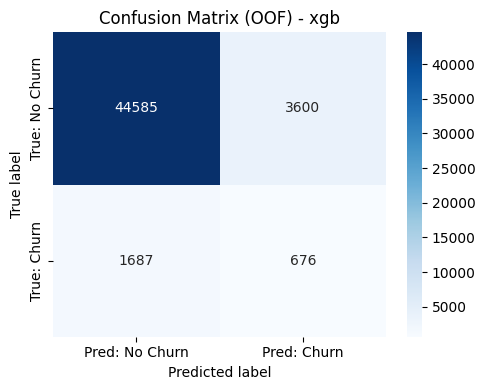

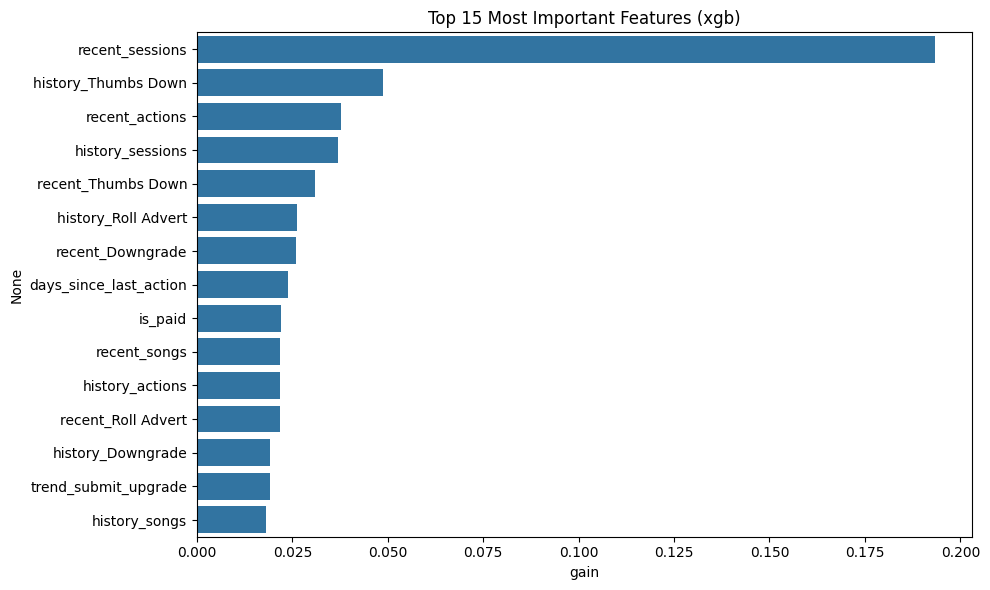


Retraining final [xgb] model on the full dataset...


In [56]:
#model, features = train_eval_model(df_train_ready, model_type="logreg")
model, features = train_eval_model(df_train_ready)
#model, features = train_eval_model(df_train_ready, model_type="rf")

In [40]:
def generate_kaggle_submission(
    model,
    df_logs_full,
    feature_cols,
    all_test_user_ids,
    output_file='submission.csv',
    seuil=0.5
):
    """
    Generate a BINARY Kaggle submission, with robust handling of ID types
    and users without activity in the final window.
    """
    print("\n--- Generating ROBUST submission file (Binary Mode) ---")

    # 1. Reference date (anchor)
    last_date = df_logs_full['time'].max()
    print(f"Anchor date: {last_date}")

    # 2. Compute features for users active around the anchor date
    X_test_active = compute_features_at_anchor(df_logs_full, last_date)

    if X_test_active is None:
        X_test_active = pd.DataFrame()
        print("Warning: No active users in the last window!")

    # 3. Predictions for active users
    if not X_test_active.empty:
        # Ensure all expected feature columns are present
        for col in feature_cols:
            if col not in X_test_active.columns:
                X_test_active[col] = 0

        # Keep the same column order as in training
        X_test_active = X_test_active[feature_cols]

        active_probs = model.predict_proba(X_test_active)[:, 1]

        df_preds = pd.DataFrame({
            'userId': X_test_active.index,
            'prediction': active_probs
        })
    else:
        df_preds = pd.DataFrame(columns=['userId', 'prediction'])

    # 4. Merge with the full test user list
    # Start from all test user IDs provided (e.g., from sample_submission or test.csv)
    final_submission = pd.DataFrame({'userId': all_test_user_ids})

    # --- IMPORTANT: Harmonize ID types so the merge works correctly ---
    final_submission['userId'] = final_submission['userId'].astype(str)
    df_preds['userId'] = df_preds['userId'].astype(str)

    # Remove potential duplicates to avoid exploding the number of rows
    final_submission = final_submission.drop_duplicates(subset=['userId'])
    df_preds = df_preds.drop_duplicates(subset=['userId'])

    # Left join: keep all test users, attach predictions where available
    final_submission = final_submission.merge(df_preds, on='userId', how='left')

    # 5. Handle missing predictions (users inactive in the last window)
    avg_proba = final_submission['prediction'].mean()
    if pd.isna(avg_proba):
        avg_proba = 0.5  # fallback if no predictions at all

    missing_count = final_submission['prediction'].isna().sum()
    print(
        f"Inactive users: {missing_count} "
        f"(filled with mean probability: {avg_proba:.4f})"
    )

    final_submission['prediction'] = final_submission['prediction'].fillna(avg_proba)

    # 6. Apply threshold to get binary churn label
    final_submission['is_churn'] = (final_submission['prediction'] >= seuil).astype(int)

    # 7. Save submission file
    output_df = final_submission[['userId', 'is_churn']]
    output_df.columns = ['id', 'target']

    output_df.to_csv(output_file, index=False)
    print(f"Saved: {output_file} ({len(output_df)} rows)")

    return output_df


In [ ]:
sample = pd.read_csv('../../../data/churn-prediction-25-26/example_submission.csv')
all_users_list = sample['id'].unique()
all_users_list

array([1128274, 1782451, 1611542, ..., 1724758, 1879724, 1749215])

In [42]:
test_set=pd.read_parquet("../../../data/churn-prediction-25-26/test.parquet")

In [51]:
submit_df = generate_kaggle_submission(model, test_set, features, all_users_list, seuil=0.6)
submit_df["target"].mean()


--- Generating ROBUST submission file (Binary Mode) ---
Anchor date: 2018-11-20 00:00:00
Inactive users: 119 (filled with mean probability: 0.4844)
Saved: submission.csv (2904 rows)


np.float64(0.23071625344352617)

np.float64(0.12293388429752067)